# The Global eSSVI surface

Calibrates `global_essvi.py` to the live Deribit BTC chain and plots the resulting
volatility surface.

What makes this surface different from one built by fitting each expiry separately is that
it is **arbitrage-free by construction**, not by inspection. The calibration optimizes over
a reparametrized box (`unbox`), every point of which maps to a surface satisfying the
no-arbitrage conditions of Mingone eq. (3) — so there is no admissible/inadmissible
boundary for the optimizer to wander across, and no repair step. Section 5 checks this
numerically, but as a test of the implementation rather than a gate on the result.

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import bs
import data
import arbitrage as arb
import global_essvi as ge

%matplotlib inline
warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True)

# ── palette ───────────────────────────────────────────────────────────────────
# One hue, light→dark, for magnitude — never a rainbow. These are the documented
# blue ramp steps; BLUE_RAMP drives the continuous (sequential) encoding and
# MATURITY_STEPS the discrete (ordinal) one.
#
# MATURITY_STEPS is five colours, not seven, and that is a computed limit rather
# than a stylistic choice: on a light surface the ramp's usable steps are spaced
# ~0.047 apart in OKLab L across a span of 0.426, and the ordinal rule wants
# adjacent steps ≥ 0.06 apart. Six steps would need every gap to be two
# quantisation units (0.094 × 5 = 0.47 > 0.426), so five is the maximum that
# validates. Five overlapping smiles also read better than seven.
BLUE_RAMP = ['#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
             '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b']
MATURITY_STEPS = ['#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b']
SEQ = LinearSegmentedColormap.from_list('essvi_blue', BLUE_RAMP)

INK, INK_2, ACCENT = '#0b0b0b', '#52514e', '#eb6834'
plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.22, 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c9c8c4', 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': INK_2, 'ytick.color': INK_2, 'axes.titlecolor': INK,
    'legend.frameon': False, 'font.size': 9,
})

## 1 — Build the surface

In [2]:
CURRENCY, MAX_T = 'BTC', 1.5

chain = ge.filter_chain(data.build_chain(data.fetch_book_summary(CURRENCY)), max_T=MAX_T)
result = ge.calibrate(**ge.chain_to_calibration_inputs(chain))
surf = result.surface

print(result)
print(f'\nconverged: {result.success} — {result.opt_result.message}')
print(f'{len(chain)} OTM quotes, {len(surf)} expiries, {3 * len(surf)} free parameters')

CalibrationResult(success=True, n_quotes=318, weighted_rmse=24.8977, GlobalESSVISurface(N=12, T=[0.005, 0.0077, 0.0105, 0.0214, 0.0406, 0.0598, 0.079, 0.1748, 0.2516, 0.3283, 0.5776, 0.8269]))

converged: True — `ftol` termination condition is satisfied.
318 OTM quotes, 12 expiries, 36 free parameters


In [3]:
params = pd.DataFrame({
    'T': surf.maturities,
    'forward': surf.forwards,
    'theta': [s.theta for s in surf.slices],
    'rho': [s.rho for s in surf.slices],
    'psi': [s.psi for s in surf.slices],
    'ATM vol': [surf.implied_vol(F, T) for F, T in zip(surf.forwards, surf.maturities)],
    'ATM skew': [s.rho * s.psi for s in surf.slices],
})
params.round(5)

,T,forward,theta,rho,psi,ATM vol,ATM skew
0,0.00498,79476.51,0.00104,0.10455,0.02049,0.45584,0.00214
1,0.00772,79488.83,0.00123,0.12416,0.02095,0.39871,0.00260
2,0.01046,79496.52,0.00163,0.14764,0.02693,0.39411,0.00398
3,0.02142,79534.70,0.00372,0.09967,0.04531,0.41647,0.00452
4,0.04060,79582.61,0.00674,0.08373,0.06027,0.40748,0.00505
5,0.05978,79647.94,0.00996,0.09005,0.07397,0.40825,0.00666
6,0.07896,79699.92,0.01275,0.05935,0.08615,0.40182,0.00511
7,0.17485,80100.61,0.02731,-0.00621,0.13485,0.39521,-0.00084
8,0.25156,80416.90,0.04123,-0.01183,0.15573,0.40484,-0.00184
9,0.32827,80715.96,0.05520,-0.03177,0.19326,0.41005,-0.00614


`theta` and `psi` are both strictly increasing down the table — that is not a property of
this particular chain, it is what `unbox` guarantees for any input. `rho` is free to move
maturity by maturity, which is exactly what eSSVI relaxes relative to SSVI's single ρ.

## 2 — The surface

The surface is plotted twice: **first over raw log-moneyness `k`, then over standardised
moneyness `z = k/√θ(T)`.** Both are drawn by `global_essvi.plot_vol_surface_pair`, which
every notebook in this project uses, so all surfaces share one camera and one colormap and
can be compared by eye.

### Why the right panel exists

A surface plotted over a fixed log-moneyness window is misleading, and badly so at the
short end. The quoted strikes here run `k ∈ [-0.11, +0.05]` at the 11-day expiry but
`[-0.79, +0.82]` at the 10-month one, because a given strike is far more standard
deviations away when there is less time for the spot to travel. Plotting both over a
common `k` window wide enough for the back end shows ±2 sd there and **±17 sd at the
front**, where the model reports vols no quote has ever constrained — an artifact of the
window, not a feature of the surface. That is the spike you can see in the first plot.

Dividing by `√θ(T)` fixes it: in `z = k/√θ` the quoted region is a consistent band of
roughly `[-2.9, +2.2]` at every maturity, so equal distances on the x-axis mean equal
probabilities and the surface can be read across the whole term structure. Each figure carries its own colour scale — compare the two axis ranges to see how much
the `k` window inflates the surface.

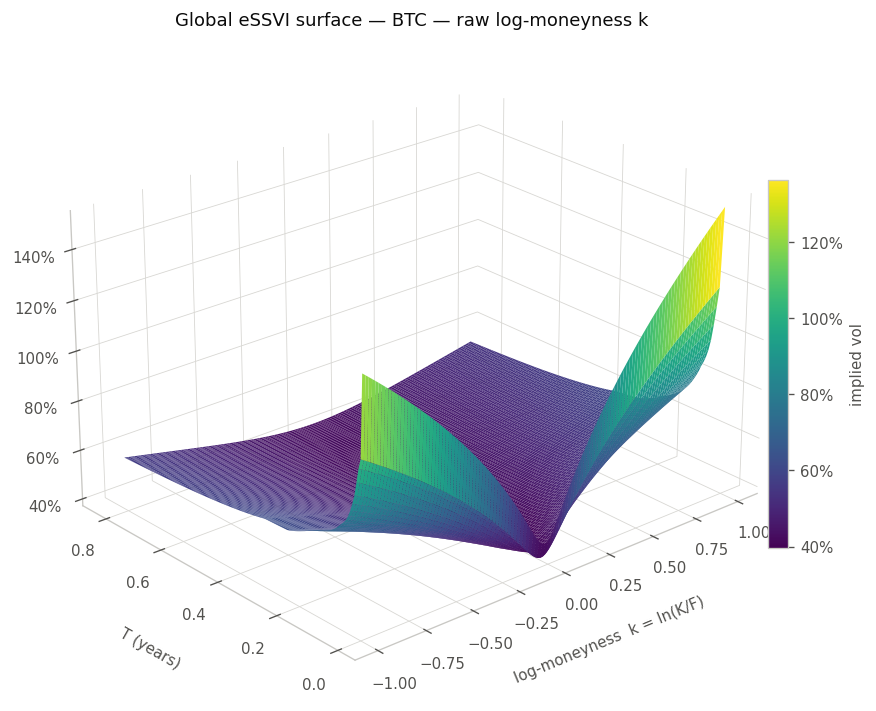

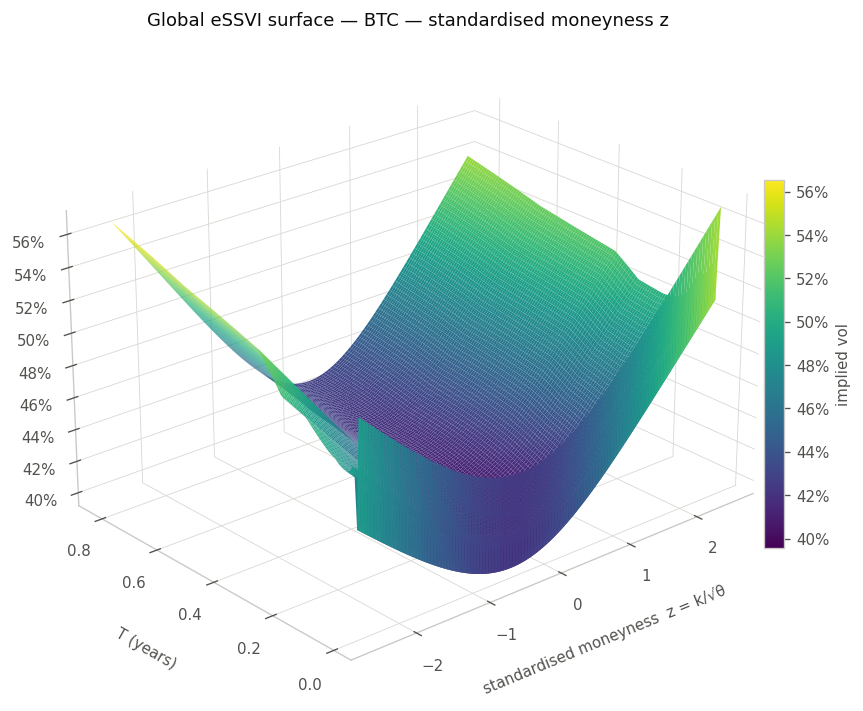

In [4]:
# Two separate figures: raw log-moneyness k, then standardised moneyness
# z = k/sqrt(theta(T)). Both come from the same `plot_vol_surface`, so they share
# one camera and one colormap with every other surface in this project.
display(ge.plot_vol_surface(surf, x_axis='k', n_k=120, n_t=120, backend='matplotlib',
                            title='Global eSSVI surface — BTC — raw log-moneyness k'))
display(ge.plot_vol_surface(surf, x_axis='z', n_k=120, n_t=120, backend='matplotlib',
                            title='Global eSSVI surface — BTC — standardised moneyness z'))

The same field as a heatmap — which is what you actually read values off, since height on a
projected surface is hard to judge and easy to occlude. Here it is drawn over raw `k`, with
everything outside the quoted strike envelope greyed out, so the calibrated region and the
extrapolated region are visibly separate.

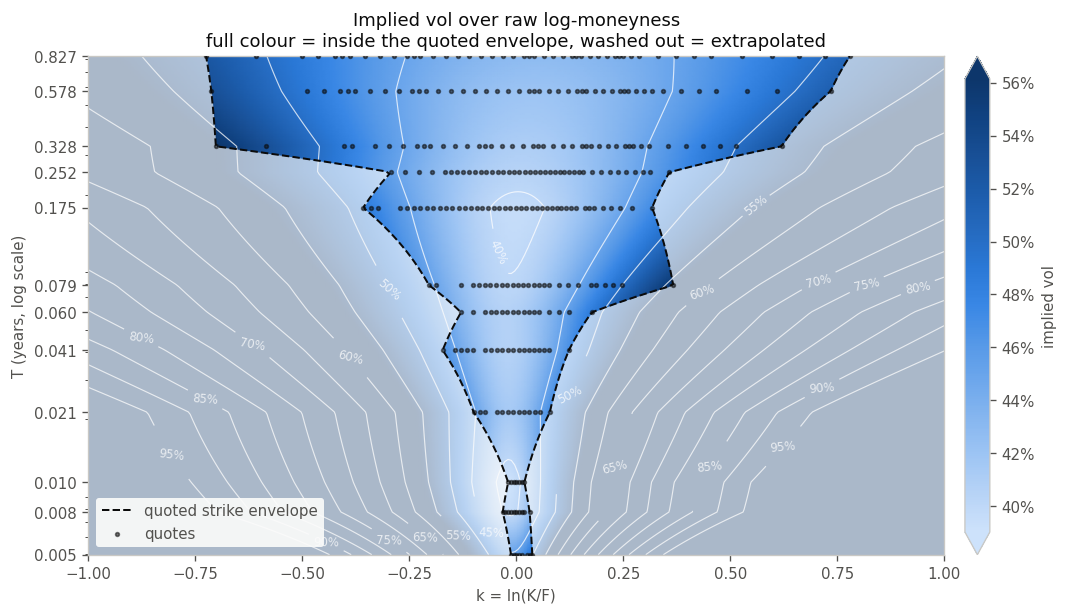

In [5]:
k_grid = np.linspace(-1.0, 1.0, 260)
t_lin = np.geomspace(surf.maturities[0], surf.maturities[-1], 200)
VOL_K = np.array([surf.implied_vol(surf.forward_at(t) * np.exp(k_grid), t) for t in t_lin])

# quoted strike envelope, interpolated between expiries
k_all = np.log(chain['strike'].to_numpy() / chain['forward'].to_numpy())
T_all = chain['T'].to_numpy()
k_lo = np.array([k_all[np.abs(T_all - t) < 1e-12].min() for t in surf.maturities])
k_hi = np.array([k_all[np.abs(T_all - t) < 1e-12].max() for t in surf.maturities])
lo_t, hi_t = np.interp(t_lin, surf.maturities, k_lo), np.interp(t_lin, surf.maturities, k_hi)
inside = (k_grid[None, :] >= lo_t[:, None]) & (k_grid[None, :] <= hi_t[:, None])

fig, ax = plt.subplots(figsize=(9.5, 5.2))

# Colour limits span exactly the calibrated region: letting the far wings set the
# range compresses everything the quotes cover into two dark steps, while clipping
# tighter than this would saturate the deep-put corner that *is* calibrated.
vmin, vmax = VOL_K[inside].min(), VOL_K[inside].max()
mesh = ax.pcolormesh(k_grid, t_lin, VOL_K, cmap=SEQ, shading='gouraud',
                     vmin=vmin, vmax=vmax)
cs = ax.contour(k_grid, t_lin, VOL_K, levels=np.arange(0.25, 1.0, 0.05),
                colors='white', linewidths=0.7, alpha=0.75)
ax.clabel(cs, inline=True, fontsize=7, fmt=lambda v: f'{v:.0%}')

# A flat vector scrim outside the envelope — an alpha'd mesh would stipple.
ax.fill_betweenx(t_lin, k_grid[0], lo_t, color='#fcfcfb', alpha=0.66, lw=0, zorder=2)
ax.fill_betweenx(t_lin, hi_t, k_grid[-1], color='#fcfcfb', alpha=0.66, lw=0, zorder=2)
ax.plot(lo_t, t_lin, color=INK, lw=1.2, ls='--', zorder=3)
ax.plot(hi_t, t_lin, color=INK, lw=1.2, ls='--', zorder=3, label='quoted strike envelope')
ax.scatter(k_all, T_all, s=5, color=INK, alpha=0.55, zorder=4, label='quotes')

ax.set_yscale('log')
ax.set_yticks(surf.maturities)
ax.set_yticklabels([f'{t:.3f}' for t in surf.maturities])
ax.set_ylim(t_lin[0], t_lin[-1])
ax.set_xlabel('k = ln(K/F)'); ax.set_ylabel('T (years, log scale)')
ax.set_title('Implied vol over raw log-moneyness\n'
             'full colour = inside the quoted envelope, washed out = extrapolated')
ax.legend(loc='lower left', labelcolor=INK_2, facecolor='#fcfcfb', framealpha=0.9,
          frameon=True, edgecolor='none')
ax.grid(False)
fig.colorbar(mesh, ax=ax, label='implied vol', pad=0.02, extend='both',
             format=lambda v, _: f'{v:.0%}')
plt.tight_layout(); plt.show()

The faded region is most of the picture, and that is the point: a surface spends most of its
life being asked for prices where nothing was quoted. Fitting each expiry independently
leaves that region unconstrained — which is where per-slice SVI fits tend to go
butterfly-negative. Here it is covered by the same guarantee as the calibrated band.

## 3 — Smiles, against the quotes that produced them

The 3-D view flatters a fit. These are the honest slices: the calibrated smile at five
maturities with the market's own bid-ask band behind it.

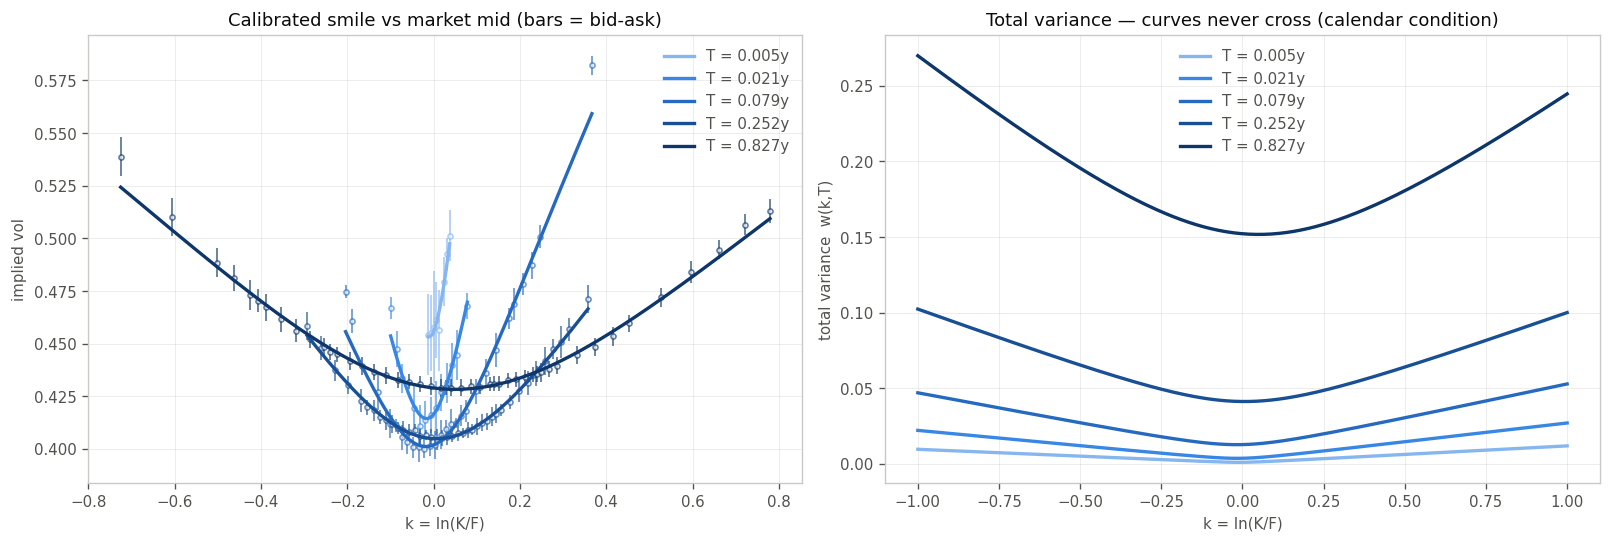

In [6]:
show_idx = np.linspace(0, len(surf.maturities) - 1, len(MATURITY_STEPS)).round().astype(int)
show_T = surf.maturities[show_idx]

half_spread = 0.5 * (chain['ask'].to_numpy() - chain['bid'].to_numpy()) / np.maximum(
    bs.vega(chain['forward'], chain['strike'], chain['T'], 0.0, 0.0, chain['mid_iv']), 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

for t, colour in zip(show_T, MATURITY_STEPS):
    m = np.abs(chain['T'].to_numpy() - t) < 1e-12
    kq = np.log(chain['strike'].to_numpy()[m] / chain['forward'].to_numpy()[m])
    o = np.argsort(kq)
    kg = np.linspace(kq.min(), kq.max(), 200)
    axes[0].plot(kg, surf.implied_vol(surf.forward_at(t) * np.exp(kg), t),
                 color=colour, lw=2, label=f'T = {t:.3f}y', zorder=3)
    axes[0].errorbar(kq[o], chain['mid_iv'].to_numpy()[m][o], yerr=half_spread[m][o],
                     fmt='o', ms=3, mfc='white', mec=colour, ecolor=colour,
                     elinewidth=1.1, alpha=0.65, lw=0, zorder=2)
axes[0].set_xlabel('k = ln(K/F)'); axes[0].set_ylabel('implied vol')
axes[0].set_title('Calibrated smile vs market mid (bars = bid-ask)')
axes[0].legend(labelcolor=INK_2)

# total variance: the quantity the no-arbitrage conditions are actually written in
for t, colour in zip(show_T, MATURITY_STEPS):
    axes[1].plot(k_grid, surf.slice_at(t).total_variance(k_grid),
                 color=colour, lw=2, label=f'T = {t:.3f}y')
axes[1].set_xlabel('k = ln(K/F)'); axes[1].set_ylabel('total variance  w(k,T)')
axes[1].set_title('Total variance — curves never cross (calendar condition)')
axes[1].legend(labelcolor=INK_2)

plt.tight_layout(); plt.show()

The right-hand panel is the calendar condition made visible: the total-variance curves
stack in maturity order and never touch. Crossing curves at any `k` would be a calendar
arbitrage — sell the near-dated, buy the far-dated at the same moneyness and bank the
difference. `unbox` makes the crossing geometrically unreachable.

## 4 — Term structure, including where there is no data

The surface is queryable at any `T > 0`, including before the first quoted expiry and
beyond the last, via Section 5's extrapolation rules. Shaded bands mark the extrapolated
regions.

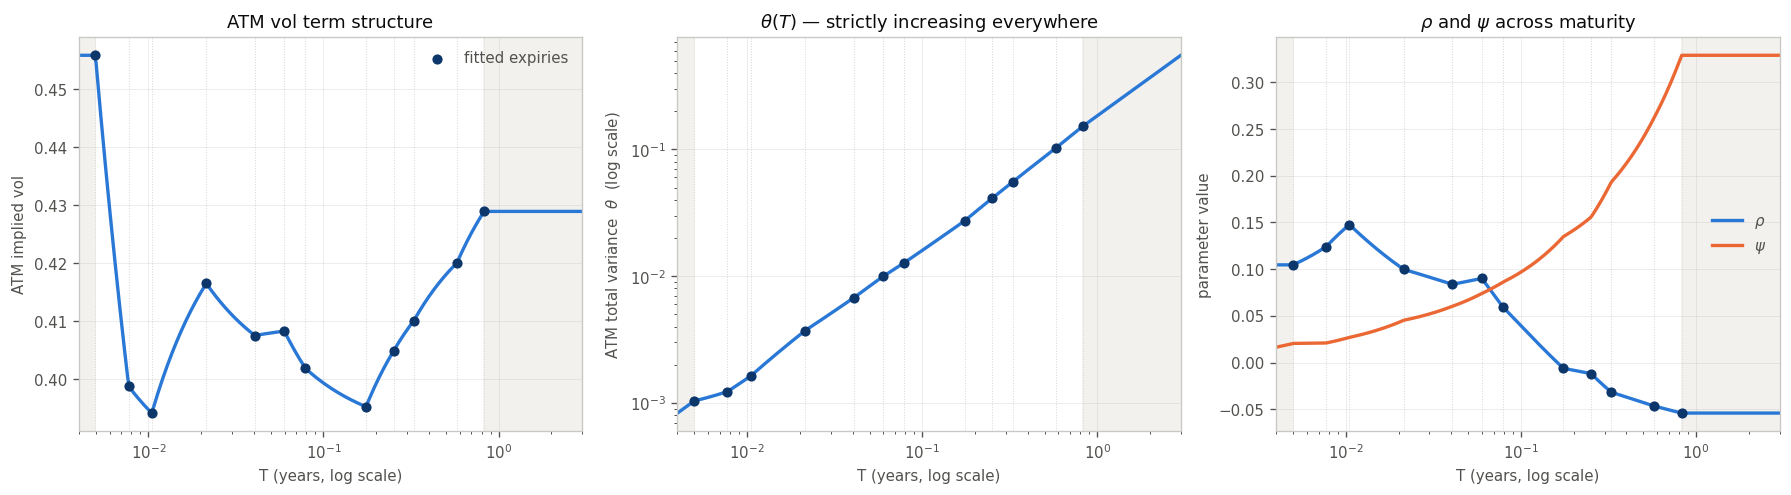

In [7]:
t_wide = np.geomspace(0.004, 3.0, 320)
T_LO, T_HI = surf.maturities[0], surf.maturities[-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))


def mark_extrapolation(ax):
    ax.axvspan(t_wide[0], T_LO, color='#f2f1ee', zorder=0)
    ax.axvspan(T_HI, t_wide[-1], color='#f2f1ee', zorder=0)
    for t in surf.maturities:
        ax.axvline(t, color='#d8d7d3', lw=0.6, ls=':', zorder=1)


atm = np.array([surf.implied_vol(surf.forward_at(t), t) for t in t_wide])
axes[0].plot(t_wide, atm, color=BLUE_RAMP[7], lw=2)
axes[0].scatter(surf.maturities, [surf.implied_vol(F, t)
                                  for F, t in zip(surf.forwards, surf.maturities)],
                s=26, color=BLUE_RAMP[12], zorder=4, label='fitted expiries')
axes[0].set_ylabel('ATM implied vol'); axes[0].set_title('ATM vol term structure')
axes[0].legend(labelcolor=INK_2)

theta = np.array([surf.slice_at(t).theta for t in t_wide])
axes[1].plot(t_wide, theta, color=BLUE_RAMP[7], lw=2)
axes[1].scatter(surf.maturities, [s.theta for s in surf.slices], s=26,
                color=BLUE_RAMP[12], zorder=4)
axes[1].set_yscale('log')  # theta spans ~3 decades; linear hides the calibrated band
axes[1].set_ylabel(r'ATM total variance  $\theta$  (log scale)')
axes[1].set_title(r'$\theta(T)$ — strictly increasing everywhere')

axes[2].plot(t_wide, [surf.slice_at(t).rho for t in t_wide], color=BLUE_RAMP[7], lw=2,
             label=r'$\rho$')
axes[2].plot(t_wide, [surf.slice_at(t).psi for t in t_wide], color=ACCENT, lw=2,
             label=r'$\psi$')
axes[2].scatter(surf.maturities, [s.rho for s in surf.slices], s=26,
                color=BLUE_RAMP[12], zorder=4)
axes[2].set_ylabel('parameter value')
axes[2].set_title(r'$\rho$ and $\psi$ across maturity')
axes[2].legend(labelcolor=INK_2)

for ax in axes:
    mark_extrapolation(ax)
    ax.set_xscale('log'); ax.set_xlabel('T (years, log scale)')
    ax.set_xlim(t_wide[0], t_wide[-1])

plt.tight_layout(); plt.show()

Three things in these panels are worth reading deliberately.

**ATM vol is exactly flat in both shaded regions, and that is correct, not a plotting
bug.** Before `T₁` the rule is `θ_t = λθ₁` with `λ = t/T₁`, so
`σ_ATM = sqrt(θ₁t/T₁ / t) = sqrt(θ₁/T₁)` — the `t` cancels identically. The same
cancellation happens past `T_N`, where `θ_t = λθ_N`. Both extrapolations are linear in
*variance*, which is flat in *vol*. It is a deliberately conservative choice: the surface
declines to invent a term structure where it has no quotes, rather than extending a trend.

**`ψ` is held constant past `T_N` while `θ` keeps growing.** Equation (3) asks for `ψ`
strictly increasing, so a validator written straight from it would flag every `t > T_N`.
It would be wrong to: with `ψ` and `ρ` fixed, `∂w/∂θ > 0` everywhere (the discriminant
exceeds `(ρψk+θ)²` by `(ψk)²(1-ρ²) ≥ 0`), so total variance still increases and no calendar
arbitrage exists. The strictness in eq. (3) is what the open-box parametrization needs to
stay a bijection, not a necessary condition for admissibility.

**`ρ` is interpolated as the ratio `(ρψ)/ψ`** of two linearly interpolated quantities,
never linearly in `ρ` itself — which is why its path between pillars is faintly curved
rather than piecewise straight. Interpolating `ρ` directly is the natural-looking shortcut
and it breaks the calendar proof, because the no-arbitrage inequalities are linear in `ψ`
and `ρψ`, not in `ρ`.

## 5 — Confirming the guarantee numerically

Proposition 3.1 already settles this, so the check below is aimed at the *implementation*:
if `unbox`, the interpolation, or the bounds had a bug, this is what would catch it. It is
run over a maturity range far wider than the quoted one, including both extrapolated tails.

check_no_arbitrage passed over 400 maturities in [0.0040, 3.00]y — no butterfly, no calendar violation


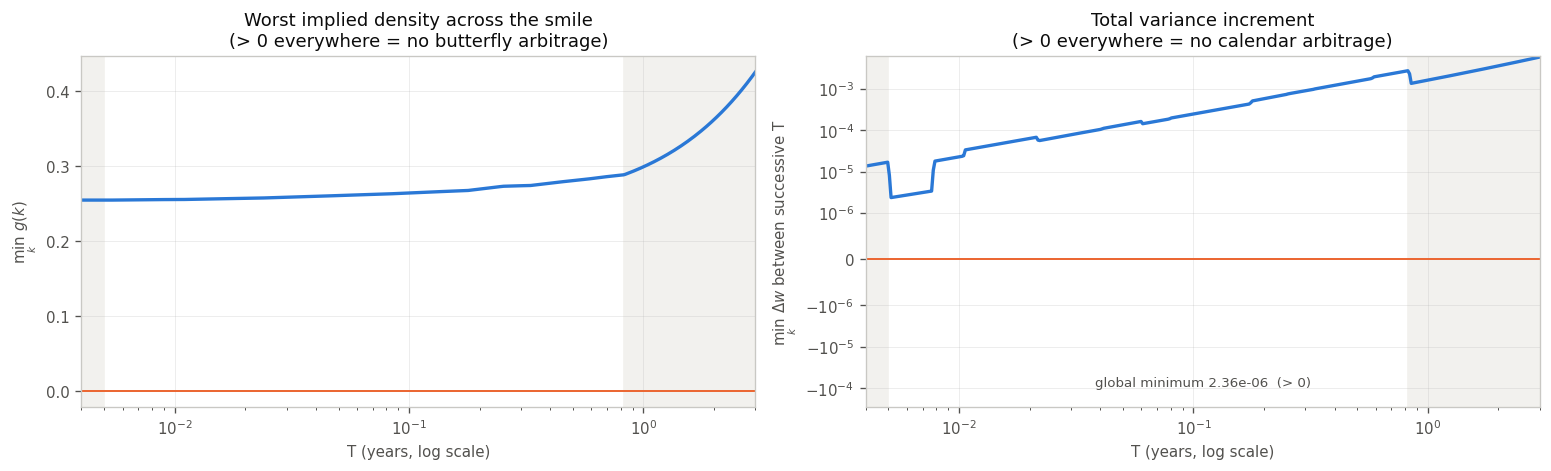

In [8]:
t_check = np.geomspace(0.004, 3.0, 400)
ge.check_no_arbitrage(surf, t_grid=t_check)
print(f'check_no_arbitrage passed over {len(t_check)} maturities in '
      f'[{t_check[0]:.4f}, {t_check[-1]:.2f}]y — no butterfly, no calendar violation')

k_dense = arb.DEFAULT_K_GRID
W = np.array([surf.slice_at(t).total_variance(k_dense) for t in t_check])
G = np.array([arb.g_function(k_dense, ge.essvi_slice_to_raw_svi(surf.slice_at(t)))
              for t in t_check])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t_check, G.min(axis=1), color=BLUE_RAMP[7], lw=2)
axes[0].axhline(0, color=ACCENT, lw=1.2)
axes[0].set_ylabel(r'$\min_k\ g(k)$')
axes[0].set_title('Worst implied density across the smile\n(> 0 everywhere = no butterfly arbitrage)')

dw_min = np.diff(W, axis=0).min(axis=1)
axes[1].plot(t_check[1:], dw_min, color=BLUE_RAMP[7], lw=2)
axes[1].axhline(0, color=ACCENT, lw=1.2)
# symlog, not log: a plain log axis silently DROPS non-positive points, so
# "the curve never goes below zero" would be true by construction of the axis
# rather than a fact about the surface. symlog renders a negative excursion.
axes[1].set_yscale('symlog', linthresh=1e-6)
axes[1].set_ylabel(r'$\min_k\ \Delta w$ between successive T')
axes[1].set_title('Total variance increment\n(> 0 everywhere = no calendar arbitrage)')
axes[1].annotate(f'global minimum {dw_min.min():.2e}  (> 0)',
                 xy=(0.5, 0.06), xycoords='axes fraction', ha='center',
                 fontsize=8, color=INK_2)

for ax in axes:
    ax.axvspan(t_check[0], T_LO, color='#f2f1ee', zorder=0)
    ax.axvspan(T_HI, t_check[-1], color='#f2f1ee', zorder=0)
    ax.set_xscale('log'); ax.set_xlabel('T (years, log scale)')
    ax.set_xlim(t_check[0], t_check[-1])

plt.tight_layout(); plt.show()

Both quantities stay strictly positive across the whole range, including the shaded
extrapolated regions where no quote constrains the fit. `min_k g(k)` dipping to zero would
mean a negative implied density; the increment touching zero would mean two maturities
crossing. Neither is reachable from inside the box.

### Using the surface

```python
surf.implied_vol(K, T)      # Black-Scholes implied vol at any strike and maturity
surf.slice_at(T)            # the (theta, rho, psi) triple at any T, interpolated
surf.total_variance(k, T)   # w(k,T) directly
surf.forward_at(T)          # the interpolated forward curve
```